# Analiza tweetów z kont zidentyfikowanych jako rosyjskie "trolle" w okresie amerykańskich wyborów prezydenckich w 2016 roku

## Autor: Michał Piątek 246747

#### Okres danych - 07.2014 do 09.2017

Tematem projektu jest analiza tweetów pochodzących z kont zidentyfikowanych zidentyfikowanych jako narzędzie do wpływania na opinie społeczne przez rosyjskie służby. Tweety te są w języku angielskim.

Link do bazy danych: https://www.kaggle.com/vikasg/russian-troll-tweets

Jako, że baza danych nie zawiera własnych oznaczeń dotyczących tego jakie emocje zawierają poszczególne tweety należało dokonać analizy własnoręcznie. Do tego celu zostały wykorzystane bazy słów negatywnych i pozytywnych dostępne pod adresami:

Pozytywne słowa: http://ptrckprry.com/course/ssd/data/positive-words.txt

Negatywne słowa: http://ptrckprry.com/course/ssd/data/negative-words.txt

Przeanalizowane zostały częstotliwości publikowania tweetów oraz zmiany ich nastrojów w czasie oraz w zaleźności od tego, o którym polityku jest w nich mowa. Pozwala to zobrazować działania propagandowe prowadzone w mediach społecznościowych.


#### Informacja wymagana przy użyciu bazy danych słów pozytywnych i negatywnych- oryginalni twórcy

   - Minqing Hu and Bing Liu. "Mining and Summarizing Customer Reviews." 
       Proceedings of the ACM SIGKDD International Conference on Knowledge 
       Discovery and Data Mining (KDD-2004), Aug 22-25, 2004, Seattle, 
       Washington, USA, 
       
   - Bing Liu, Minqing Hu and Junsheng Cheng. "Opinion Observer: Analyzing 
       and Comparing Opinions on the Web." Proceedings of the 14th 
       International World Wide Web conference (WWW-2005), May 10-14, 
       2005, Chiba, Japan.

## Narzędzia oraz paczki

Do stworzenia programu został wykorzystany język Python wraz z widocznymi poniżej paczkami. Jako środowisko został wykorzystany jupyter-notebook.

Wykorzystana została też technika usuwania tzw. "stopwords", która wymaga dodatkowego pobrania listy tych słów.

Dane można pobrać i zainstalować uruchamiając interpreter Pythona w terminalu i wprowadzając

```   
>>> import nltk   
>>> nltk.download('stopwords')
```
Wymagane paczki to **pandas**, **numpy**, **matplotlib**, **re** oraz **ntlk**.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib
import matplotlib.pyplot as plt 
import nltk
from nltk.stem.porter import *
from nltk.stem.snowball import SnowballStemmer
from wordcloud import WordCloud
from collections import Counter
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.probability import FreqDist

# Konfiguracja romziaru czcionki w wykresach
matplotlib.rcParams.update({'font.size': 12})


Tutaj następuje wczytanie pliku csv z bazą danych do DataFrame.

In [2]:
# Converter pozwala uniknąć zaokrąglania id (widzi je jako duże liczby)
tweets = pd.read_csv('./russian-troll-tweets/tweets.csv',converters={i: str for i in range(0, 100)})

In [4]:
tweets.describe()

,user_id,user_key,created_at,created_str,retweet_count,retweeted,favorite_count,text,tweet_id,source,hashtags,expanded_urls,posted,mentions,retweeted_status_id,in_reply_to_status_id
count,203482,203482,203482,203482,203482,203482,203482,203482,203482,203482,203482,203482,203482,203482,203482,203482
unique,394,454,198422,198422,1230,2,1168,175215,200662,20,18343,22215,1,16683,32354,517
top,1679279490,ameliebaldwin,,,,,,"RT @MarkAlmost: MT @jstines3: Dear LORD, pleas...",,,[],[],POSTED,[],,
freq,9269,9269,21,21,145399,145399,145399,30,2314,145398,114696,173789,203482,163964,163831,202923


# Preprocessing tweetów

Następnym krokiem jest wstępne przetwarzanie zbioru danych w celu uzyskania tekstu gotowego do oceny.

Pierwszą zmianą jest usunięcie niepotrzebnych kolumn.

In [3]:
# Usuwanie niepotrzebnych kolumn
tweets = tweets.drop(columns=['user_id','created_at', 'tweet_id','retweet_count','retweeted','favorite_count','mentions','retweeted_status_id',
                             'in_reply_to_status_id','source','expanded_urls','posted'])

W tweetach jest też duża ilość elementów mających swoje źródło w samej specyfice serwisu i nie wnoszą one wiele informacji do naszej analizy nastrojów. Więc także należy się ich pozbyć.

Dlatego kolejnym krokiem jest usunięcie z tekstów tweetów zawierających się w kolumnie ***text*** wszystkich oznaczeć przekazywania innych tweetów (tzw. retweet, w tekście ***RT***) oraz oznaczeń innych użytkowników w formie ***@użytkownik***.

Osiągnięte to zostało za pomocą znajdywania wszystkich łańcuchów znaków odpowiadających wyrażeniu regularnemu i usuwaniu ich.

In [4]:
# Usuwanie nazw użytkownika i oznaczenia retweet'a 
def remove_pattern(input_txt, pattern):
    r = re.findall(pattern, input_txt)
    for i in r:
        input_txt = re.sub(i, '', input_txt)
        
    return input_txt  

tweets['tidy_tweet'] = np.vectorize(remove_pattern)(tweets['text'], "RT @[\w]*:")

W podobny sposób dane zostały oczyszczone z linków, które z racji różnej swojej formy musiały być usuwane za pomocą różnych wyrażeń regularnych.

In [5]:
# Usuwanie linków
def remove_pattern(input_txt, pattern):
    r = re.findall(pattern, input_txt)
    for i in r:
        input_txt = re.sub(i, '', input_txt)
        
    return input_txt  

tweets['tidy_tweet'] = np.vectorize(remove_pattern)(tweets['tidy_tweet'], "[\s]*http[s]*:\/\/t.co\/[\S]{10}")
tweets['tidy_tweet'] = np.vectorize(remove_pattern)(tweets['tidy_tweet'], "[\s]*http:\/\/t.co\/[\S]{10}")
tweets['tidy_tweet'] = np.vectorize(remove_pattern)(tweets['tidy_tweet'], "[\s]*https[\s]*")
tweets['tidy_tweet'] = np.vectorize(remove_pattern)(tweets['tidy_tweet'], "[\s]*http[\s]*")

Następnie zostały usunięte wszystkie znaki niealfanumeryczne.

In [6]:
# Usuwanie znaków niealfanumerycznych
tweets['tidy_tweet'] = tweets['tidy_tweet'].str.replace("[^a-zA-Z]", " ")

In [7]:
tweets.head(5)

,user_key,created_str,text,hashtags,tidy_tweet
0,ryanmaxwell_1,2016-03-22 18:31:42,#IslamKills Are you trying to say that there w...,"[""IslamKills""]",IslamKills Are you trying to say that there w...
1,detroitdailynew,2016-10-10 20:57:00,"Clinton: Trump should’ve apologized more, atta...",[],Clinton Trump should ve apologized more atta...
2,cookncooks,2017-02-22 12:43:43,RT @ltapoll: Who was/is the best president of ...,[],Who was is the best president of the past ...
3,queenofthewo,2016-12-26 15:06:41,RT @jww372: I don't have to guess your religio...,"[""ChristmasAftermath""]",I don t have to guess your religion Christm...
4,mrclydepratt,2017-08-06 02:36:24,RT @Shareblue: Pence and his lawyers decided w...,[],Pence and his lawyers decided which of his of...


W tekście pisanym wiele słów bierze się z samych zasad językowych a nie wnosi wiele treści. Takie słowa nazywane są w języku angielskim "stopwords". I właśnie z powodu tego, iż chcemy, żeby tekst miał jak najmniej bezużytecznych informacji te słowa też usuwamy

In [8]:
# Stopwords
stop_words=set(stopwords.words("english"))

In [9]:
# Usuwanie stopwords
tweets['tidy_tweet'] = tweets['tidy_tweet'].apply(lambda x: ' '.join([w for w in x.split() if w not in stop_words]))

### Tokenizacja i Lematyzacja

Terminy te określają techniki przetwarzania tekstu w celu zastosowania go właśnie do algorytmów określania nastroju. 

Tokenizacja polega na rozbijaniu większych struktur jak np. zdania na mniejsze jak np. słowa. W tym przypadku tweety rozbijane są na pojedyncze słowa

Lemmatyzacja polega na sprowadzaniu słów do ich form bazowych np. cats do cat albo leaves do leaf. Używa ona leksykalnych baz danych dla danego języka aby określić formę bazową słowa. Podobnym procesem jest stemming ale lematyzacja mimo, że jest bardziej intensywna i wolniejsza to daje lepsze rezultaty i jest dokładniejsza. Sprowadzanie słów do form bazowych sprawiam, że mimo tego, że te same słowa mogą być napisane w różnej formie, to będą poprawnie uznawane za znaczące to samo.


In [10]:
# Tokenizacja
tokenized_tweet = tweets['tidy_tweet'].apply(lambda x: word_tokenize(x))

In [11]:
# Lematyzacja
lemmatizer = WordNetLemmatizer() 

tokenized_tweet = tokenized_tweet.apply(lambda x: [lemmatizer.lemmatize(i) for i in x])

Tutaj do kolumny z przetworzony tweetem zostaje wprowadzona jego wartość po całym procesie wstępnego przetwarzania.

In [12]:
# Ponowne wprowadzenie danych do kolumny po lematyzacji
for i in range(len(tokenized_tweet)):
    tokenized_tweet[i] = ' '.join(tokenized_tweet[i])

tweets['tidy_tweet'] = tokenized_tweet

Ostatnim krokiem we wstępnym przetwarzaniu jest ograniczenie danych dot. czasu opublikowania tweeta do miesiąca i roku.

In [13]:
# Preprocessing dat - ograniczenie danych o czasie opublikowania tweeta do miesiąca i roku
tweets['created_str'] = tweets['created_str'].apply(lambda x: x[:7] )

# Popularne słowa we wszystkich tweetach - Wordcloud

Chmura tagów(ang. "wordcloud") jest sposobem obrazowania najczęściej występujących słów. 

Tutaj jest ona tworzona dla wszystkich tweetów.

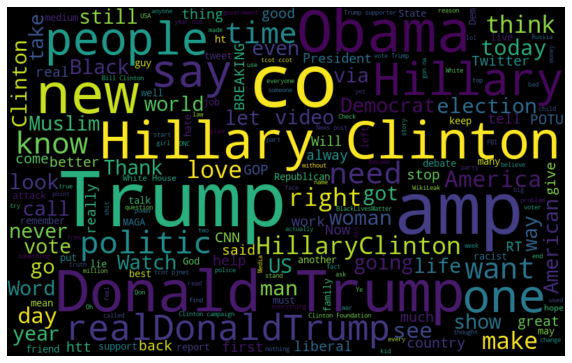

In [15]:
all_words = ' '.join([text for text in tweets['tidy_tweet']])
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.savefig('tweets_wordcloud.png')
plt.show()

# Badanie hashtagów dla wszystkich tweetów

Hashtagi dostarczają wielu ważnych informacji. Zostały stworzone do tego, żeby grupować tweety o podobnej tematyce i przeanalizowanie ich pozwoli nam zauważyć pewne trendy w nastrojach badanych użytkowników tweetera.

Kolumna ***hashtags*** zawiera hashtagi występujące w tweetcie, niestety ma ona formę ciągu znaków z niepotrzebnymi wartościami takimi jak np. nawiasy kwadratowe, czy przecinki. Muszą być one usunięte.

In [16]:
# Przetwarzanie kolumny "hashtags"
tweets['hashtags'] = tweets['hashtags'].str.replace("[^a-zA-Z0-9]", " ")

Następnym krokiem jest wyciągnięcie wszystkich hashtagów z bazy danych oraz przypisanie im miesiąca oraz roku, w którym zostały użyte w celu analizy ich występowania w zależności od czasu.

In [17]:
hashtags_timeseries = []
def hashtags_timeseries_extract(row,output_list,person=None):
    tags = re.findall(r'#(\w+)', row['text'])
    time = row['created_str'][:7]
    if(person != None):
        if(row['subject_name'] == person):
            for tag in tags:
                output_list.append([tag,time])
    else:
        for tag in tags:
            output_list.append([tag,time])
        
tweets.apply(hashtags_timeseries_extract,output_list=hashtags_timeseries , axis=1)

0         None
1         None
2         None
3         None
4         None
          ... 
203477    None
203478    None
203479    None
203480    None
203481    None
Length: 203482, dtype: object

Dla większej możliwości operowania na zebranych danych lista została przekształcona w DataFrame

In [18]:
# Zamiana listy na DataFrame
hashtags_time_df = pd.DataFrame(hashtags_timeseries, columns=['tag','date'])

Na tym etapie pozostała nam wizualizacja zebranych danych. Najpierw segregujemy je na listy hashtagów w zależności od czasu ich użycia, listę 15 najczęstszych hashtagów oraz tworzymy chmurę tagów, żeby móc zobrazować najczęstsze z nich.

In [19]:
# Grupowanie ilości hashtagów w zależności od czasu
tags_time = hashtags_time_df.groupby('date').count().reset_index()

In [64]:
# Zliczanie najczęstszych hashtagów
top_tags = hashtags_time_df['tag'].value_counts().reset_index().head(15)

,index,tag
0,politics,3638
1,tcot,2839
2,MAGA,2538
3,PJNET,2147
4,news,2046
5,Trump,1851
6,Merkelmussbleiben,1108
7,TrumpForPresident,1088
8,WakeUpAmerica,1061
9,NeverHillary,976


Biorąc pod uwagę, że operacja miała na celu wspieranie kandydatury Donalda Trumpa nie dziwi fakt, że najwięcej tagów dotyczyło treści konserwatywnych. Lecz zaskakującym jest fakt, że też często były używane tagi takie jak "Merkelmussbleiben" - wskazujące, że te konta były też używane do krytykowania Angeli Merkel.Zaskakująco popularny był też "#SurvivalGuideToThanksgiving" - tag nawiązującey do amerykańskich świąt dziękczynienia.

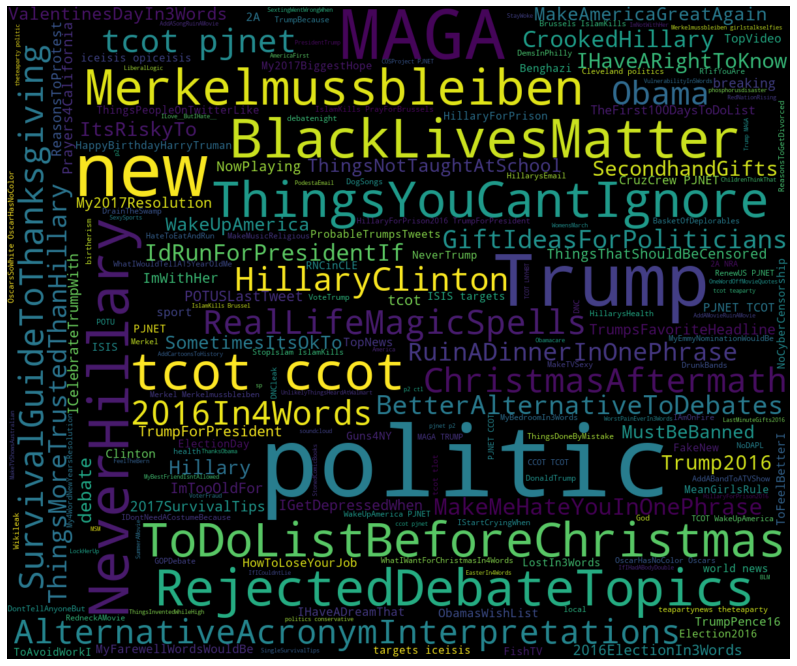

In [21]:
# Chmura wszystkich hashtagów
all_tags = ' '.join([text for text in hashtags_time_df['tag']])
wordcloud = WordCloud(width=1200, height=1000, random_state=21, max_font_size=150).generate(all_tags)

plt.figure(figsize=(16, 12))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.savefig('all_tags_wordcloud.png')
plt.show()

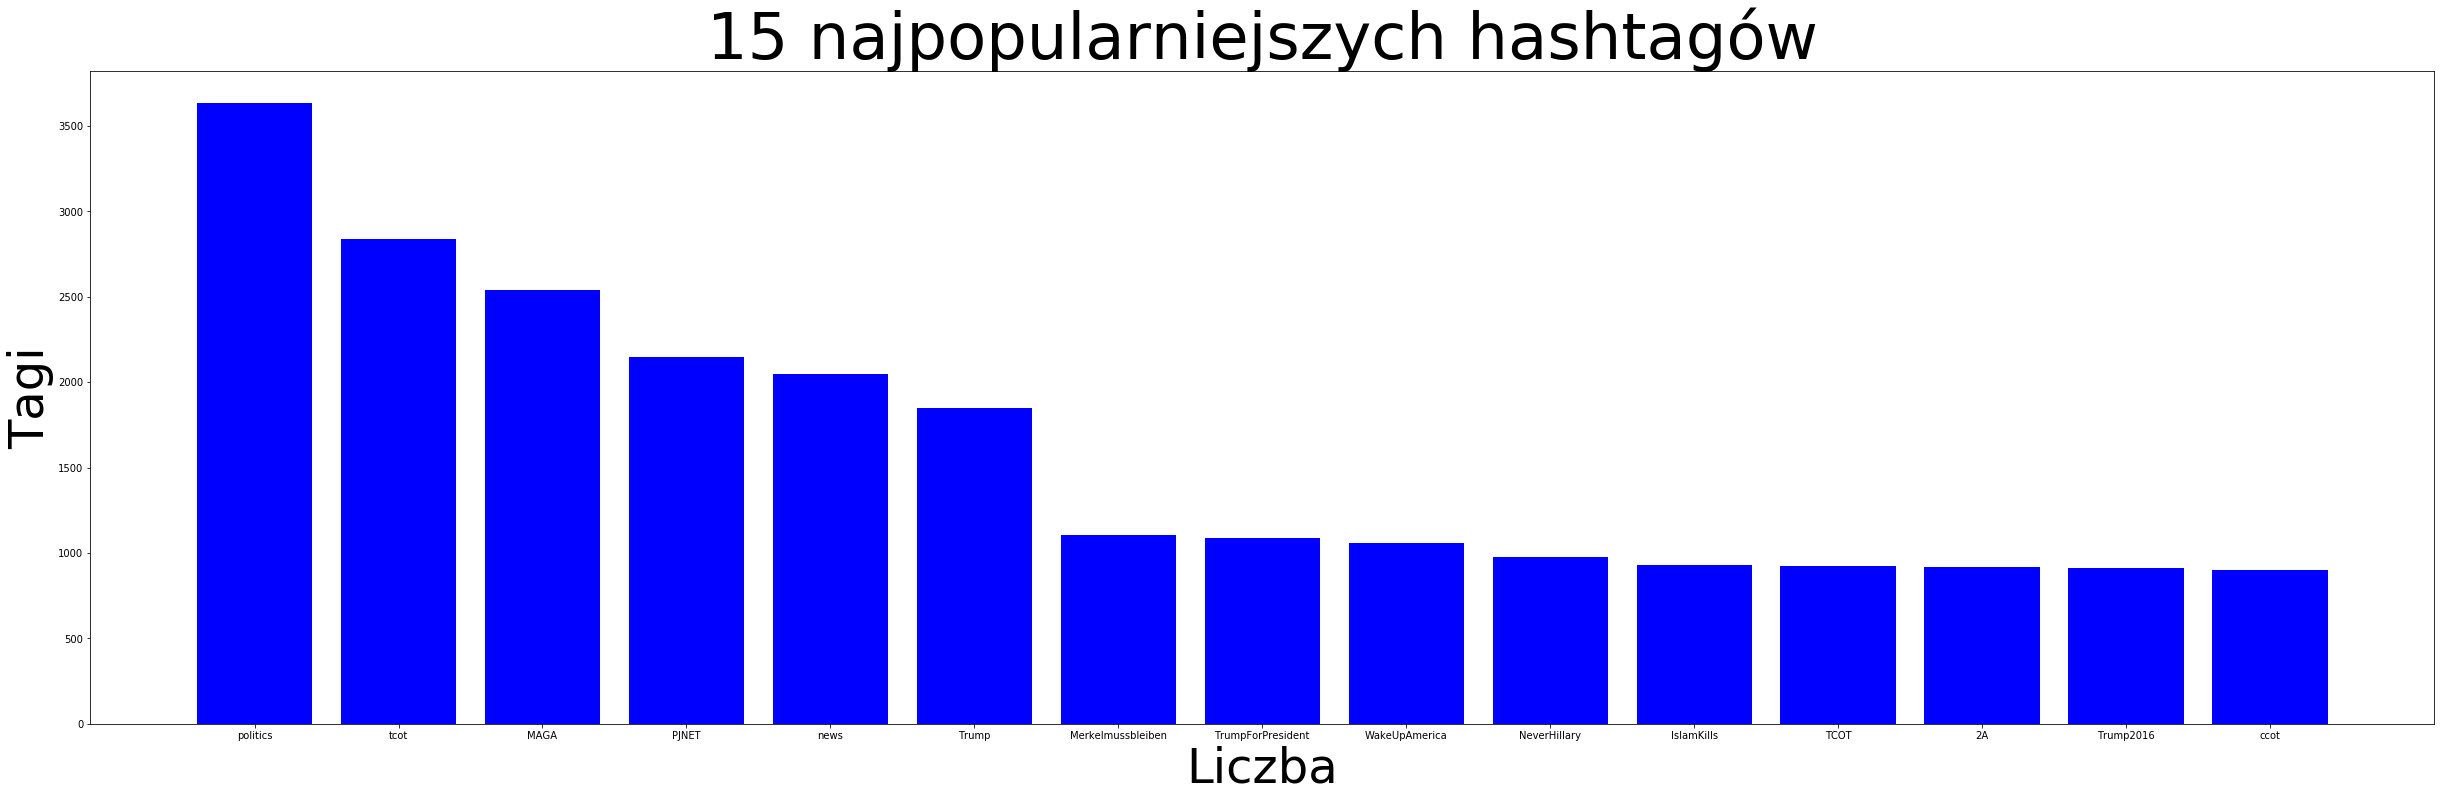

In [74]:
# Top 15 hashtagów
plt.figure(figsize=(42,12))
plt.bar(top_tags['index'], top_tags['tag'], color="blue", )
plt.ylabel('Tagi', fontsize=48)
plt.xlabel('Liczba', fontsize=48)
plt.title('15 najpopularniejszych hashtagów', fontsize=64)
plt.savefig('top_15_tags.png')
plt.show()

Na wykresie można zauważyć, że najwięcej hashtagóœ zaczęto używać w okolicy samych wyborów (11-2016) a także przy nominacjach (tzw. "primaries") w lutym 2016.

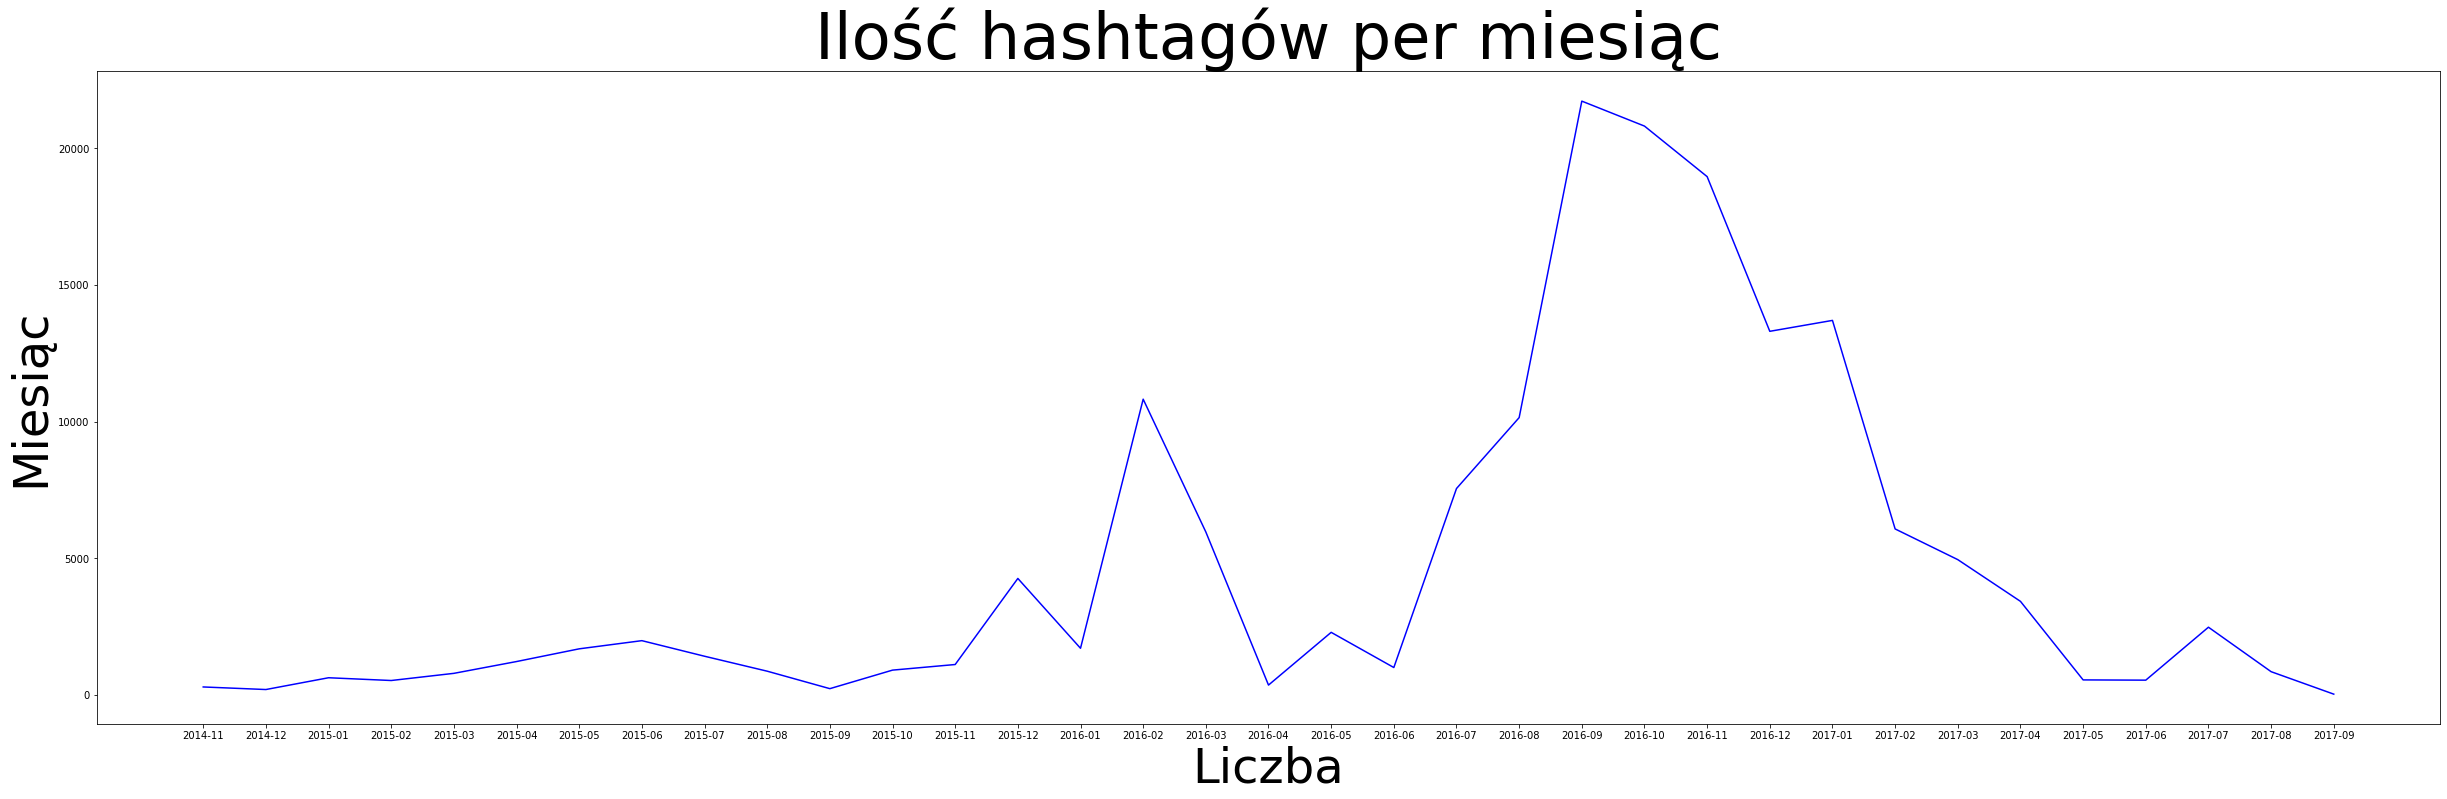

In [75]:
# Ilość hashtagów per miesiąc
plt.figure(figsize=(42,12))
plt.plot(tags_time['date'], tags_time['tag'], color="blue")
plt.ylabel('Liczba', fontsize=48)
plt.xlabel('Miesiąc', fontsize=48)
plt.title('Ilość hashtagów per miesiąc', fontsize=64)
plt.savefig('tags_per_month.png')
plt.show()

# Klasyfikacja przez zliczanie pozytywnych/negatywnych słów w tweetach

Na tym etapie następuje ważna część analizy tego zbioru danych - analiza nastrojów.

Została ona dokonana metodą zliczania pozytywnych i negatywnych słów i obliczania różnicy ich ilości w tweetcie.
Na początek do osobnych list zostały wprowadzone słowa pozytywne i negatywne w języku angielskim.

Ocena w kolumnie ***score*** przyjmuje wartości ujemne, dodatnie albo 0. Dodatnie wartości wskazują na pozytywny nastrój, ujemne przeciwnie. 0 oznacza, że nastrój był zrównoważony albo tweet nie zawierał żadnych słów wskazujących na stan emocjonalny.

In [3]:
# Negatywne słowa
negative = []
with open('negative-words.txt','r+') as file:
    for line in file:
        negative.extend(line.split())


In [4]:
# Pozytywne słowa
positive = []
with open('positive-words.txt','r+') as file:
    for line in file:
        positive.extend(line.split())

Potem można przejść do samej klasyfikacji. Tworzona jest funkcja pomocnicza zliczająca wszystkie słowa występujące w tweecie z listy podanej jako parametr(słowa negatywne bądź pozytywne). Potem wszystkie negatywne oraz pozytywne słowa wraz z różnicą ilości ich wystąpień są dodawane do listy ***sentiment_list***. 

In [26]:
# Wyszukuje wszystkie słowa z przekazanej listy w tweetcie (listy zwierają negatywne/pozytywne słowa)
def list_search(text,output_list,sentiment_list):
    for key in text:
        if (key in sentiment_list):
            output_list.append(key)
    return output_list

sentiment_list = []


# Generowanie listy z pozytywnymi i negatywnymi terminami w każdym tweetcie oraz obliczanie jego ogólnego
# sentymentu(nastroju) na zasadzie ilosć pozytywnych słow - ilość negatywnych słów.
def calculate_sentiment(tweet):
    list_neg = []
    list_pos= []
    
    text = tweet.split()
    list_search(text,list_neg,negative)
    list_search(text,list_pos,positive)
    
    sentiment_list.append({'neg': list_neg, 'pos': list_pos, 'score': (len(list_pos) - len(list_neg))  })

tweets['tidy_tweet'].apply(calculate_sentiment)

0         None
1         None
2         None
3         None
4         None
          ... 
203477    None
203478    None
203479    None
203480    None
203481    None
Name: tidy_tweet, Length: 203482, dtype: object

Po skończeniu analizy nastroju jej wyniki z wcześniej stworzonej listy zostają dodane jako kolumna do głównego DataFrame.

In [27]:
# Dodawanie listy z wartościami nastroju tweetów do tabeli 
scores_list = []
for line in sentiment_list:
    scores_list.append(line['score'])
tweets['scores'] = scores_list

Tutaj widać jak wyglądają tweety o najbardziej skrajnych nastrojach wg. algorytmu. Widać, że najbardziej negatywny tweet jest wg. użytej metryki bardziej negatywny od najbardziej pozytywnego. 

In [28]:
# Wypisanie kilku tweetów o najbardziej skrajnych wartościach nastroju (największe/najmniejsze)
tweets.sort_values(by='scores', ascending=True)

,user_key,created_str,text,hashtags,tidy_tweet,scores
117834,prettylaraplace,2016-09,RT @ChristiChat: #SickHillary can be defined s...,SickHillary Trump maga,SickHillary defined many way sick ailing sick ...,-10
98825,hyddrox,2017-03,"RT @LenoraJ16: abhorrent, atrocious, bitter, d...",,abhorrent atrocious bitter detestable egregiou...,-9
65990,jani_s_jac,2016-11,"RT @thepoliticalcat: Rude, lewd, crude, jealou...",,Rude lewd crude jealous vain envious vengeful ...,-8
96731,ameliebaldwin,2017-01,RT @MomentumOx: Not the fault of poverty/inequ...,,Not fault poverty inequality Not fault horrifi...,-7
104239,jacquelinisbest,2017-01,"RT @MarcheWasRight: ""complex mess"" \r\nhow the...",,complex mess fuck si complex fucking mong cunt...,-7
...,...,...,...,...,...,...
9034,puredavie,2016-08,RT @JunkyWithAMonkE: #TweepAQuote It's like th...,TweepAQuote,TweepAQuote It like like KattFunny like uh lik...,6
135543,ameliebaldwin,2016-09,RT @joshgremillion: .@realDonaldTrump is ready...,,realDonaldTrump ready lead prosper amp succeed...,6
152584,michellearry,2016-11,#thingspeopleontwitterlike they like likes. Th...,ThingsPeopleOnTwitterLike,thingspeopleontwitterlike like like This I lea...,6
55006,westernwindwes,2015-05,"You are good enough, smart enough, beautiful e...",,You good enough smart enough beautiful enough ...,7


## Analiza nastrojów w tweetach

Po zklasyfikowaniu nastroju w każdym tweecie można dokonać wizualizacji, żeby dostrzec trendy w nastroju albo aktywności.

Wizualizacje przedstawiają sumę nastrojów tweetóœ oraz ich średnią z każdego badanego miesiąca. Suma pozwala nam stwierdzić jaki i jak intensywny był nastrój wiadomości całej populacji badanych użytkowników natomiast średnia obrazuje te metryki per użytkownik.

In [29]:
# Ogólna suma nastrojów grupowana miesiącami
score_time_sum = tweets.groupby('created_str').sum().reset_index()
score_time_sum = score_time_sum.iloc[1:,]

In [30]:
# Średnia nastrojów grupowana miesiącami
score_time_avg = tweets.groupby('created_str').mean().reset_index()
score_time_avg = score_time_avg.iloc[1:,]

Suma sentymentów - jeśli sentymenty są poniżej zera to oznacza, że tweety są generalnie negatywne. Można zauważyć duży spadek w okolicach listopada 2016 - miesiąca, w którym odbywały się wybory w USA.

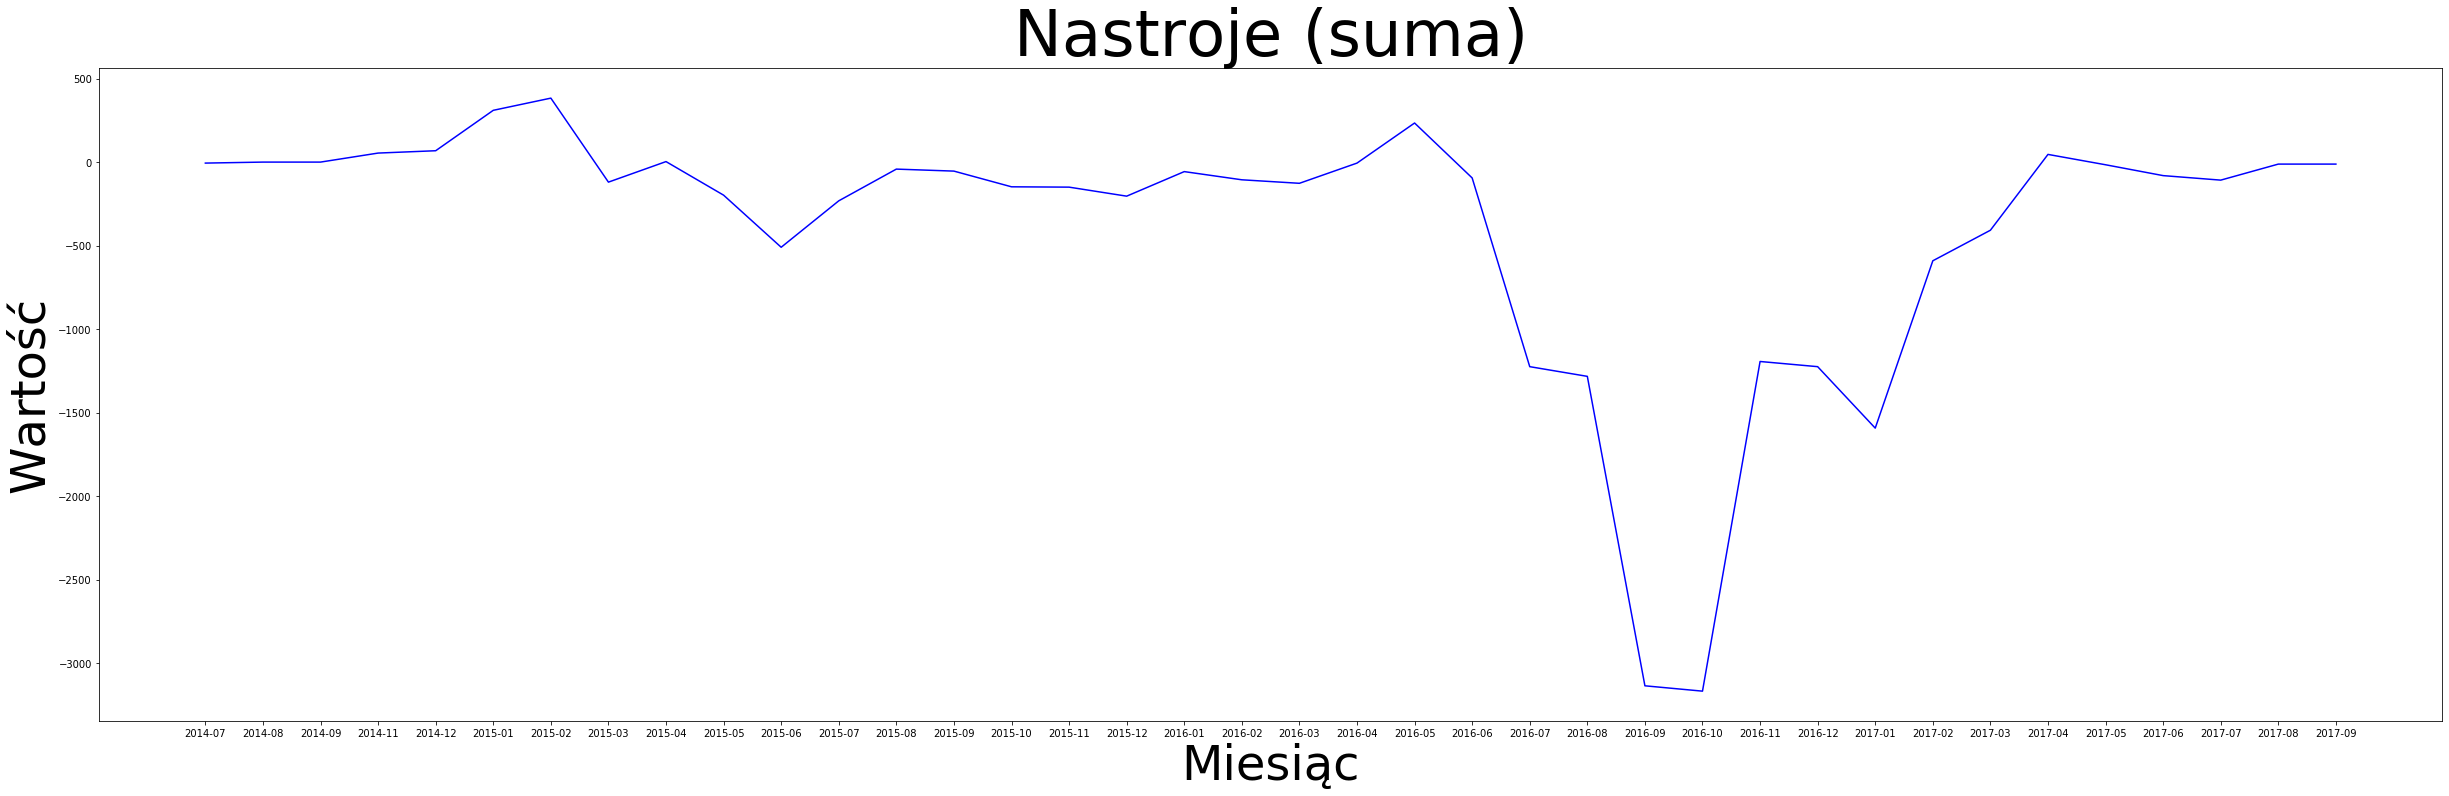

In [77]:
# Tutaj widać duży spadek nastrojów blisko wyborów - 2016-11
plt.figure(figsize=(42,12))
plt.plot(score_time_sum['created_str'], score_time_sum['scores'], color="blue")
plt.ylabel('Wartość', fontsize=48)
plt.xlabel('Miesiąc', fontsize=48)
plt.title('Nastroje (suma)', fontsize=64)
plt.savefig('sentiment_sum.png')

plt.show()

Podobne można zauważyć przy wykresie średniego nastroju każdego użytkownika.

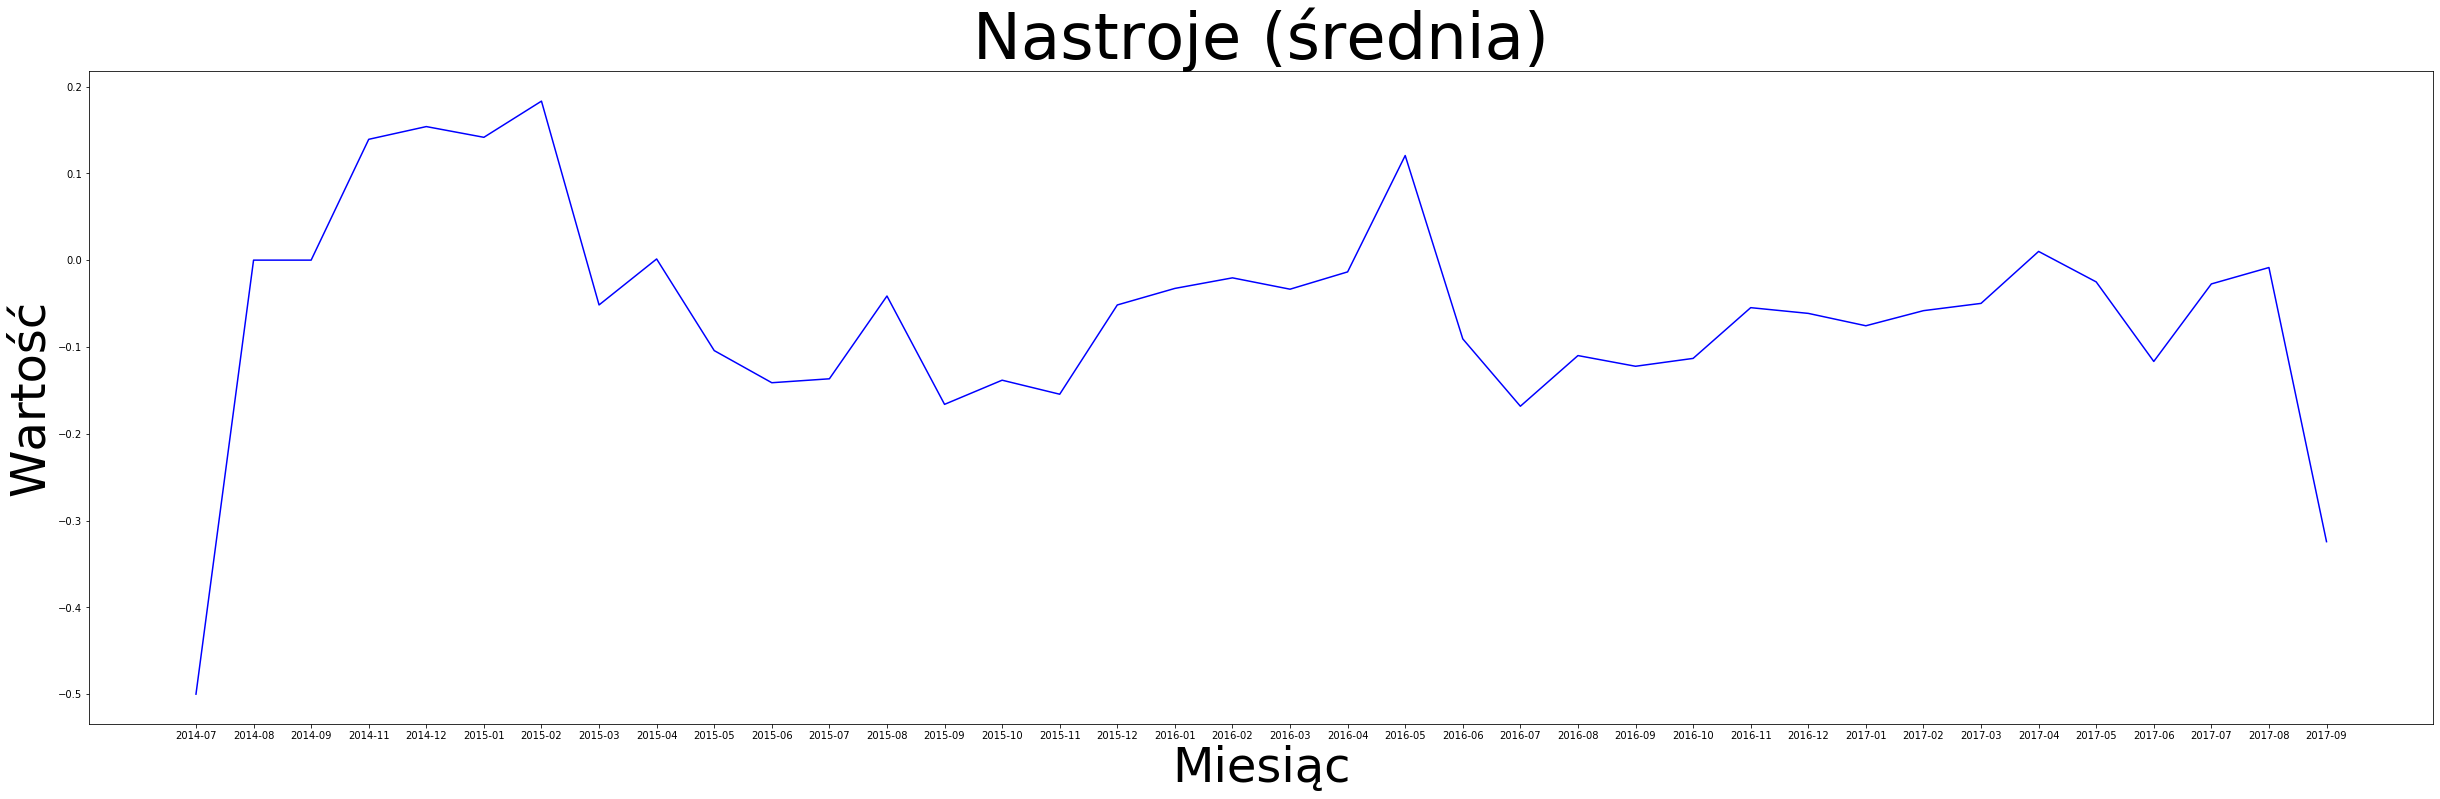

In [78]:
plt.figure(figsize=(42,12))
plt.plot(score_time_avg['created_str'], score_time_avg['scores'], color="blue")
plt.ylabel('Wartość', fontsize=48)
plt.xlabel('Miesiąc', fontsize=48)
plt.title('Nastroje (średnia)', fontsize=64)
plt.savefig('sentiment_avg.png')
plt.show()

Na obu wykresach można zauważyć, że 2 lata przed wyborami konta publikowały dość pozytywne treści - można wysunąć wniosek, że było to chociażby przygotowanie odpowiednio bogatej historii aktywności na koncie w celu nie wzbudzania podejrzeń.

Tutaj można zauważyć jak zmieniała się aktywność na przestrzeni miesięcy i podobnie widać duży skok aktywności w okolicy wyborów.

In [33]:
# Zliczanie ilości tweetów per miesiąc
number_per_mo = tweets.groupby('created_str').count().reset_index()
number_per_mo = number_per_mo.iloc[1:,]

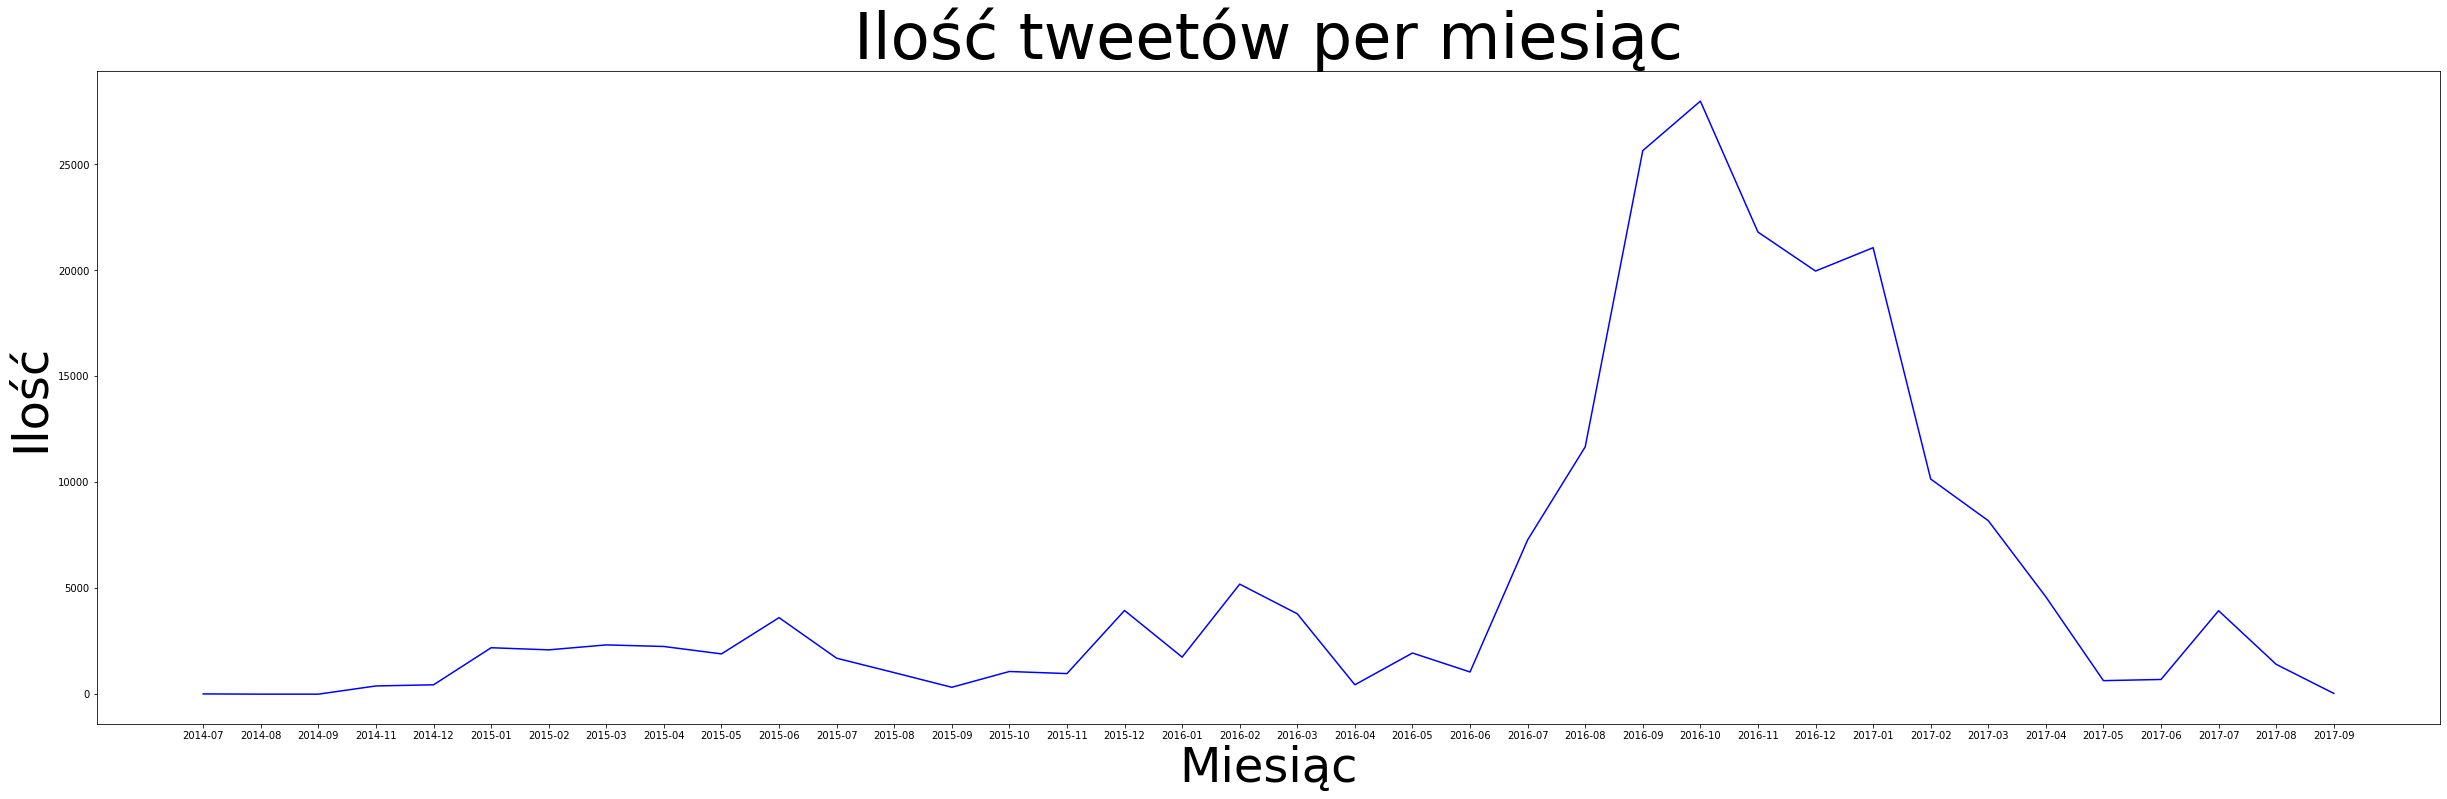

In [80]:
# Wykres ilości tweetów per miesiąc

plt.figure(figsize=(42,12))
plt.plot(number_per_mo['created_str'], number_per_mo['scores'], color="blue")
plt.ylabel('Ilość', fontsize=48)
plt.xlabel('Miesiąc', fontsize=48)
plt.title('Ilość tweetów per miesiąc', fontsize=64)
plt.savefig('tweets_per_month.png')
plt.show()

Zostały też zwizualizowane średnie nastroje 20 najbardziej pozytywnych i negatywnych użytkowników.

In [35]:
# Średni nastrój najbardziej negatywnych i najbardziej pozytywnych użytkowników

avg_by_user = tweets.groupby('user_key').mean().reset_index()

avg_sent_by_user_lowest = avg_by_user.sort_values(by='scores', ascending=True).head(20)

avg_sent_by_user_highest = avg_by_user.sort_values(by='scores', ascending=False).head(20)

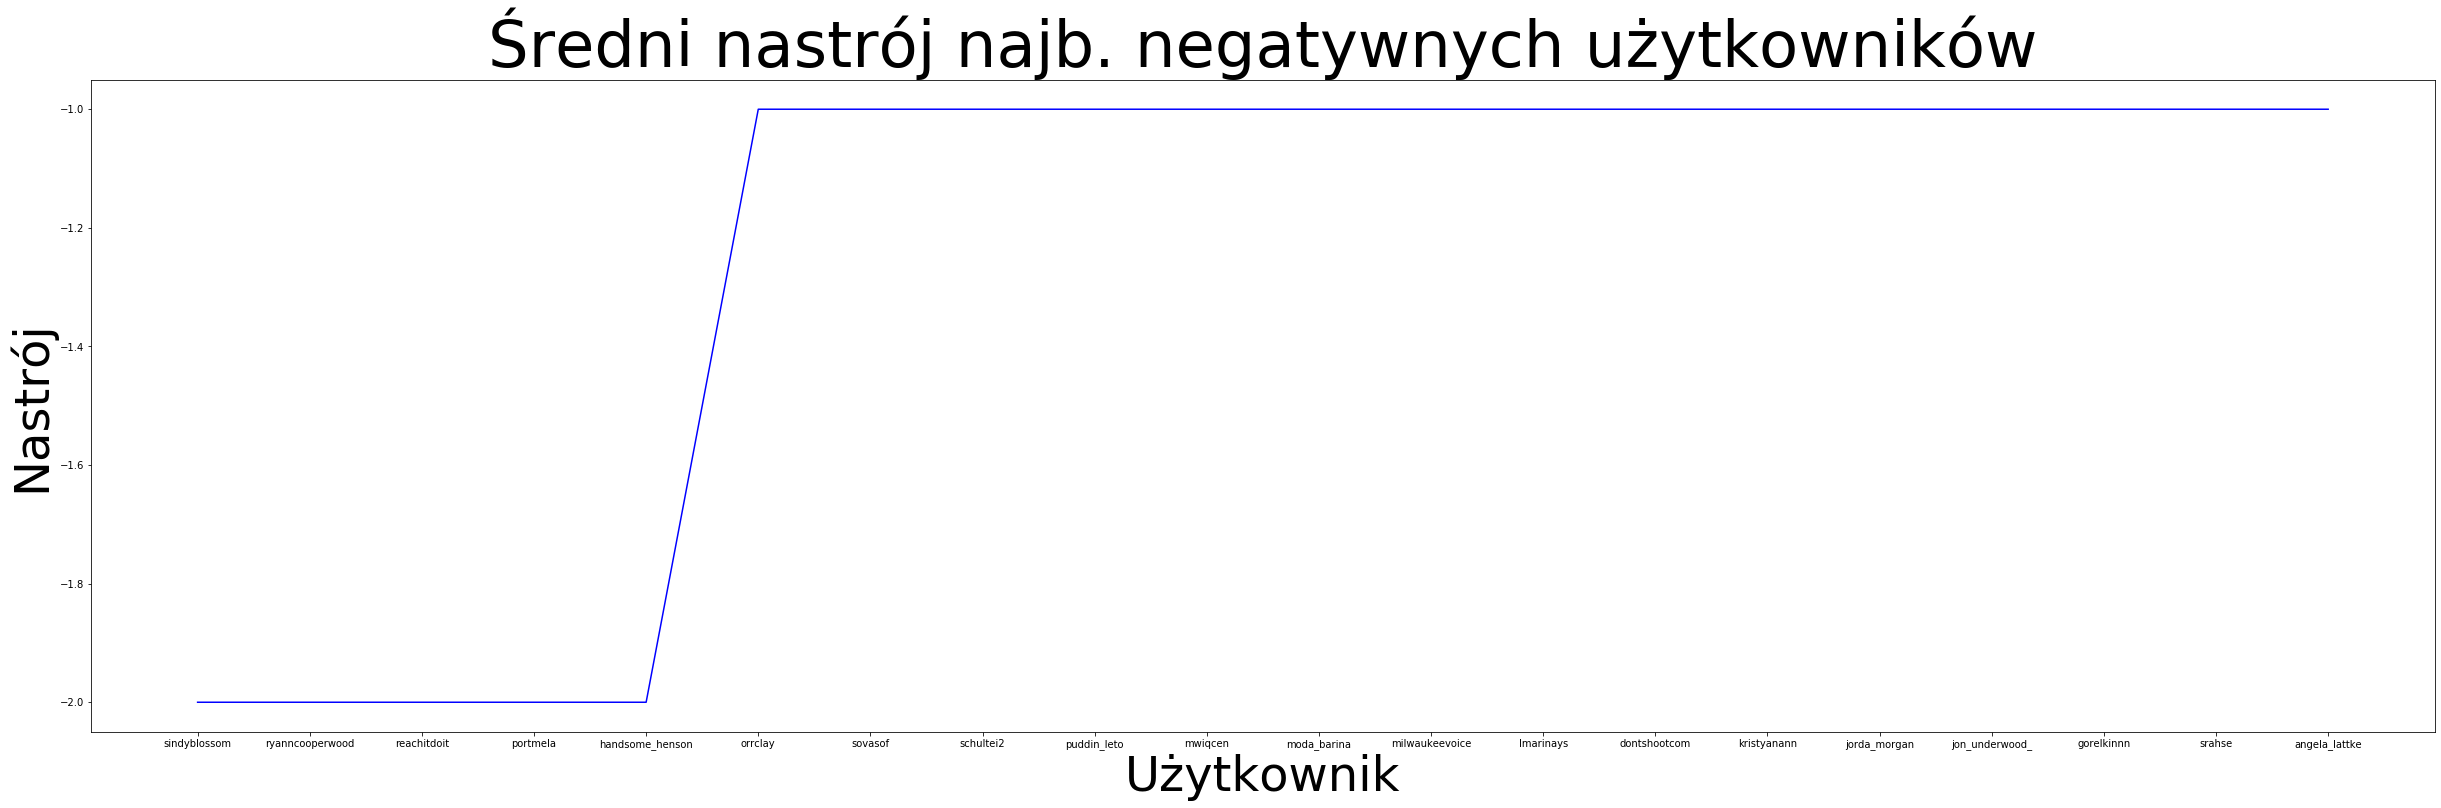

In [81]:
# Wykres średniego sentymentu tweetów "najgorszych" użytkowników
plt.figure(figsize=(42,12))
plt.plot(avg_sent_by_user_lowest['user_key'], avg_sent_by_user_lowest['scores'], color="blue")
plt.ylabel('Nastrój', fontsize=48)
plt.xlabel('Użytkownik', fontsize=48)
plt.title('Średni nastrój najb. negatywnych użytkowników', fontsize=64)
plt.savefig('avg_sentiment_worst_users.png')

plt.show()

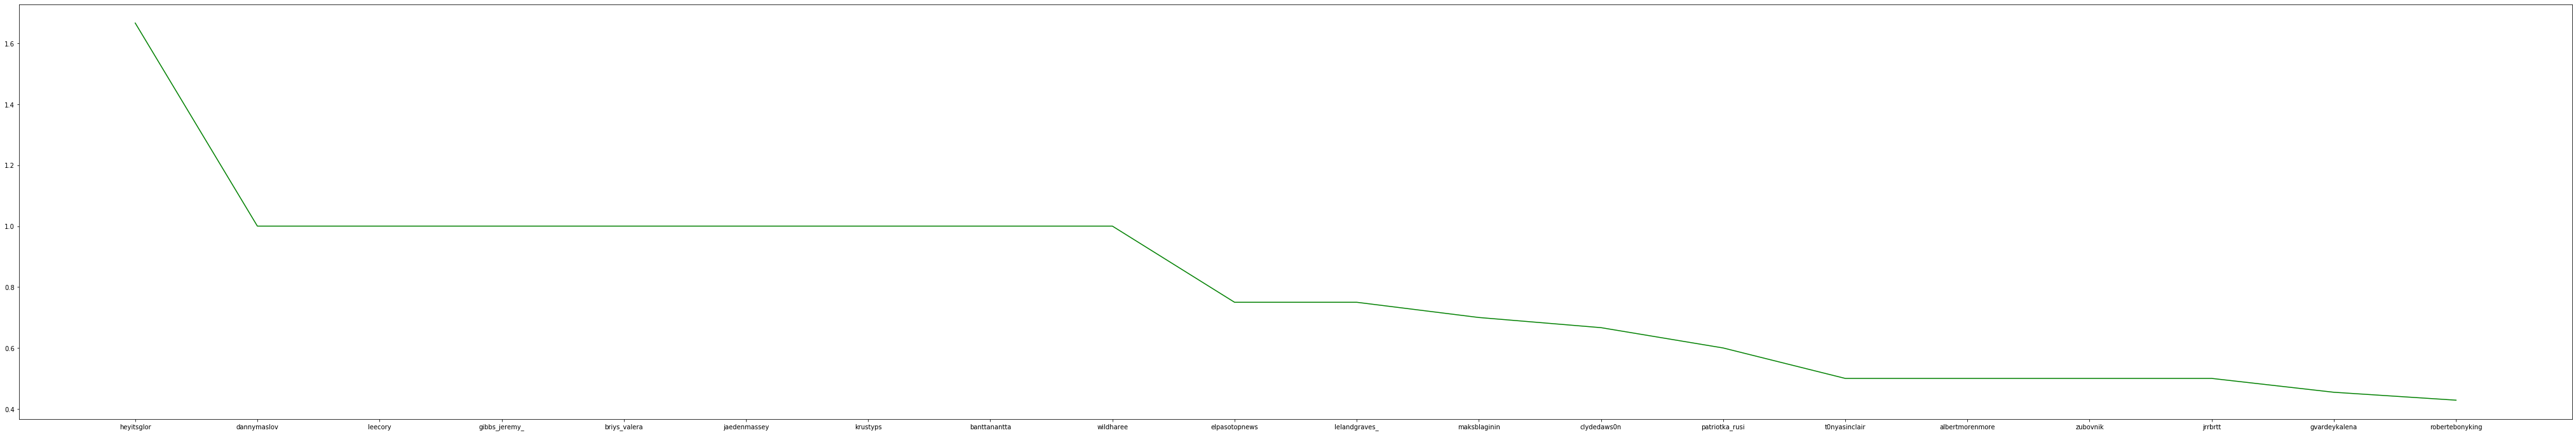

In [37]:
# Wykres średniego sentymentu tweetów "najlepszych" użytkowników

plt.figure(figsize=(72,12))

plt.plot(avg_sent_by_user_highest['user_key'], avg_sent_by_user_highest['scores'], color="green")
plt.ylabel('Nastrój', fontsize=48)
plt.xlabel('Użytkownik', fontsize=48)
plt.title('Średni nastrój najb. pozytywnych użytkowników', fontsize=64)
plt.savefig('avg_sentiment_best_users.png'
plt.show()

## Analiza opinii na temat polityków

Ważne jest też aby spojrzeć jak kształtują się nastroje w tweetach traktujących o konkretnych politykach. Tutaj skupić się należy na głównych kandydatach na prezydenta w 2016: Hillary Clinton, Donalda Trumpa oraz ówcześnie urzędującego prezydenta Baracka Obamy.

Najpierw należy ustalić, o jakim polityku w tweecie jest mowa oraz czy w ogóle są oni wspominani. Została zastosowana do tego metoda zliczania ile razy dany polityk został wspomniany w każdym tweetcie. Jeśli żaden polityk nie pojawił się w tekście tweetu to ustawiana jest etykieta "brak". Następnie podobnie jak wcześniej lista z wartościami zostanie dodana do DataFrame tweets jako osobna kolumna ***subject_name***.

In [38]:
# Zwracanie klucza o maksymalnej wartości w słowniku
def keywithmaxval(d):
     """ a) create a list of the dict's keys and values; 
         b) return the key with the max value"""  
     v=list(d.values())
     k=list(d.keys())
     return k[v.index(max(v))]

In [39]:
# Wykres analizujący średni sentyment do polityka (średni sentyment tweetóœ zawierających nazwisko np. Trump)

# Preprocessing danych
def name_search(text,name):
    counter = 0
    for key in text:
        if name.upper() in key.upper():
            counter += 1
    return counter

In [40]:
# Wykrywanie czy i o jakim polityku jest mowa w tweecie
person_in_tweet = []

def identify_name(tweet):
    
    text = tweet.split()
    
    trump_num = name_search(text,"trump")
    hillary_num = name_search(text,"hillary")
    obama_num = name_search(text,"obama")
    freq_dict = {'trump': trump_num, 'hillary': hillary_num, 'obama': obama_num}
    
    most_freq_name = keywithmaxval(freq_dict)
    
    number = freq_dict.get(most_freq_name)
    if(number > 0):
        person_in_tweet.append({'name':most_freq_name, 'num_of_occur':freq_dict.get(most_freq_name)})
    else:
        person_in_tweet.append({'name':'brak', 'num_of_occur':freq_dict.get(most_freq_name)})

tweets['tidy_tweet'].apply(identify_name)

0         None
1         None
2         None
3         None
4         None
          ... 
203477    None
203478    None
203479    None
203480    None
203481    None
Name: tidy_tweet, Length: 203482, dtype: object

In [41]:
# Dodawanie imion z listy jako kolumny do DataFrame tweets
names_list = []
for line in person_in_tweet:
    names_list.append(line['name'])
tweets['subject_name'] = names_list

Następnie w celu analizy został wyliczony średni nastrój dla każdego polityka.

Wyniki jednoznacznie wskazują, że użytkownicy najbardziej negatywnie odnosili się do Hillary Clinton i Baracka Obamy a najbardziej przychylnie do Donalda Trumpa. Bazując na wiedzy jaką opcję polityczną wspierała kampania rosyjskich służb te wyniki są spodziewane. 

In [42]:
# Średni nastrój tweeta w zależności od polityka, o któ©ym on jest
avg_sentiment_by_name = tweets.groupby('subject_name').mean().reset_index()

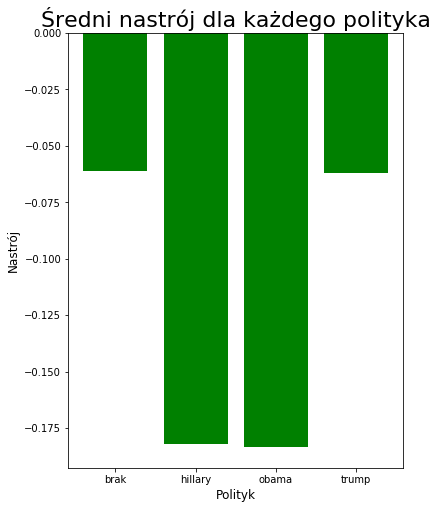

In [85]:
# Wykres średniego sentymentu dla każdego polityka - trump ma najniższy a clinton i obama najwyższy

plt.figure(figsize=(6,8))
plt.bar(avg_sentiment_by_name['subject_name'], avg_sentiment_by_name['scores'], color="green")
plt.ylabel('Nastrój', fontsize=12)
plt.xlabel('Polityk', fontsize=12)
plt.title('Średni nastrój dla każdego polityka', fontsize=22)
plt.show()

# Analiza hashtagów per polityk

Podobnie jak analiza hashtagów dla wszystkich tweetów można zanalizować jakie hashtagi najczęściej pojawiały się w tweetach dotyczących poszczególnych polityków. 

Dla każdego polityka do osobnych DataFrame zostały wyciągnięte hashtagi z tweetów ich dotyczących oraz zobrazowane w formie chmury tagów.

In [44]:
# Wykrycie hashtagów dla tweetów o Trumpie
trump_tags = []
tweets.apply(hashtags_timeseries_extract,output_list=trump_tags, person='trump' , axis=1)
trump_tags_df = pd.DataFrame(trump_tags, columns=['tag','date'])

In [45]:
# Wykrycie hashtagów dla tweetów o Hillary Clinton
hillary_tags = []
tweets.apply(hashtags_timeseries_extract,output_list=hillary_tags, person='hillary' , axis=1)
hillary_tags_df = pd.DataFrame(hillary_tags, columns=['tag','date'])

In [46]:
# Wykrycie hashtagów dla tweetów o Obamie
obama_tags = []
tweets.apply(hashtags_timeseries_extract,output_list=obama_tags, person='obama' , axis=1)
obama_tags_df = pd.DataFrame(obama_tags, columns=['tag','date'])

Hashtagi z tweetów dot. Trumpa głównie są hasłami jego kampanii - "MAGA, MakeAmericaGreatAgain" oraz krytykujące Hillary Clinton - "NeverHillary, CrookedHillary". Potwierdza to też wyniki średniego nastroju w tweetach o Trumpie, ponieważ widać, że wspierały one jego kampanie przekazując dalej jego hasła wyborcze. 

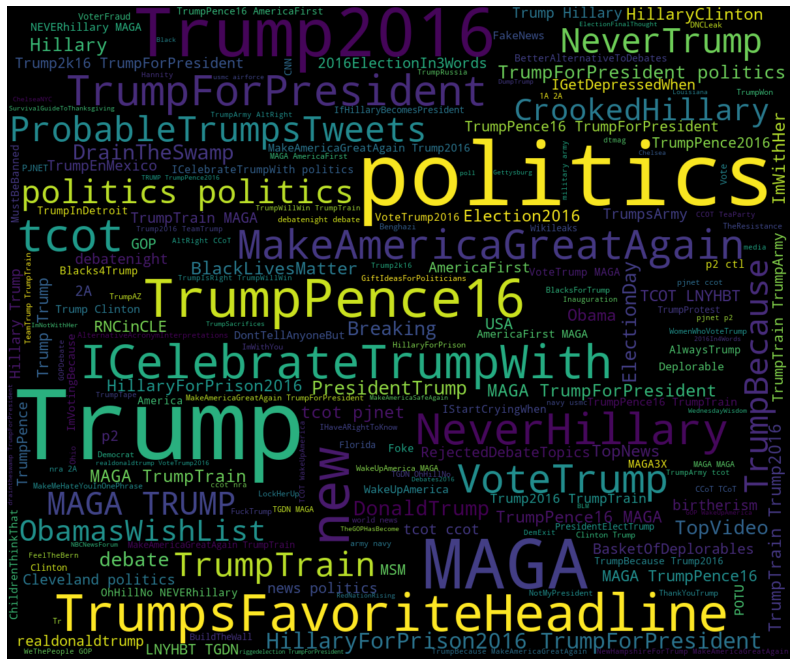

In [47]:
# Wordcloud hashtagów dla Trumpa
trump_cloud = ' '.join([text for text in trump_tags_df['tag']])
wordcloud = WordCloud(width=1200, height=1000, random_state=21, max_font_size=150).generate(trump_cloud)

plt.figure(figsize=(16, 12))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.savefig('trump_tags_wordcloud.png')
plt.show()

W przeciwieństwie do Trumpa hashtagi w tweetach dot. Hillary Clinton widać, że są one jednoznacznie negatywne - np. "NeverHillary, HillaryForPrison". Podobnie potwierdza to wcześniejsze obserwacje dot. nastrojów.

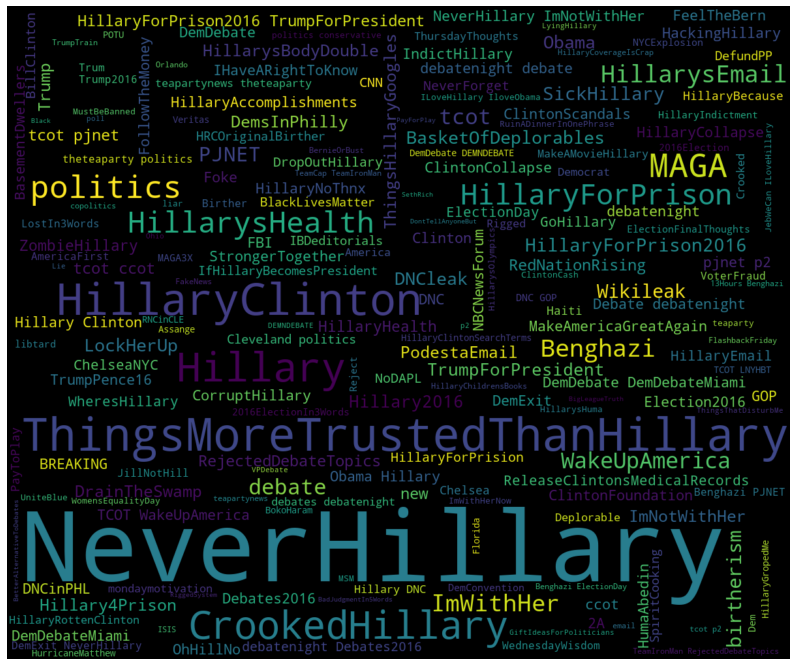

In [48]:
# Wordcloud hashtagów dla Hillary
hillary_cloud = ' '.join([text for text in hillary_tags_df['tag']])
wordcloud = WordCloud(width=1200, height=1000, random_state=21, max_font_size=150).generate(hillary_cloud)

plt.figure(figsize=(16, 12))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.savefig('hillary_tags_wordcloud.png')

plt.show()

W tweetach dot. Obamy można też zauważyć, że tweety były negatywne lecz nie aż w takim stopniu jak te o Hillary Clinton. Widać tutaj głównie tagi traktujące o jego decyzjach(np. "Obamacare") i je krytykujących tak jak ironiczne "ThanksObama". 

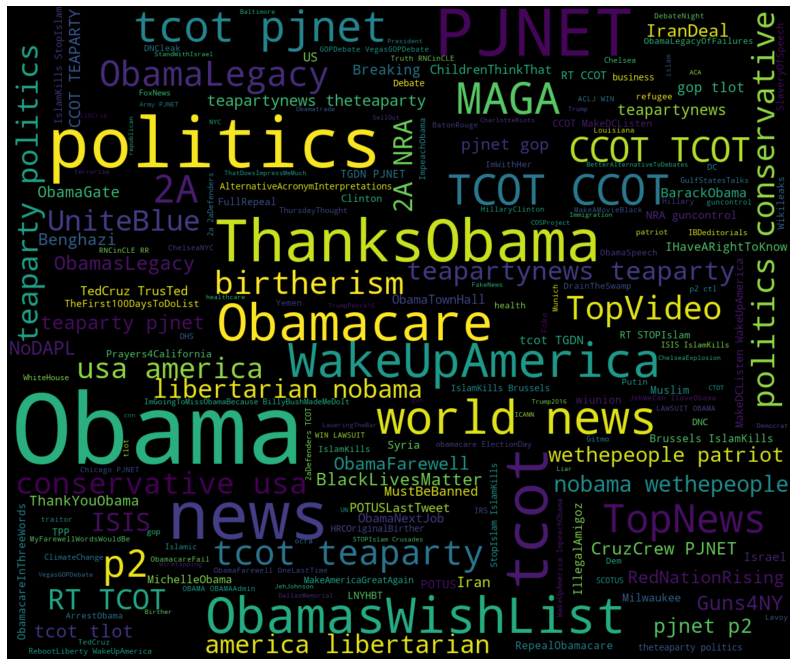

In [49]:
# Wordcloud hashtagów dla Obamy
obama_cloud = ' '.join([text for text in obama_tags_df['tag']])
wordcloud = WordCloud(width=1200, height=1000, random_state=21, max_font_size=150).generate(obama_cloud)

plt.figure(figsize=(16, 12))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.savefig('obama_tags_wordcloud.png')

plt.show()

# Podsumowanie

Wnioski z przedstawionej analizy danych jasno wskazują, kto był wspierany a kto krytykowany podczas wyborów w USA w 2016 roku. Taka analiza jest przydatna sprawdzenia, którzy kandydaci są lubiani, a którzy nie. Pokazana też tutaj analiza hashtagów pozwala ponadto łatwo zauważyć na jakie trendy warto zwrócić większą uwagę przy dalszej analizie nastrojów społecznych wokół ważnych wydarzeń politycznych.